# Lab 2 Q3
Training is done by `train.py` (one Habrok job per hyperparameter setting).

| Hyperparameter | Below | Baseline | Above |
|:--------------:|:-----:|:--------:|:-----:|
| Learning rate | 1e-4 | 1e-3 | 1e-2 |
| Batch size| 4 | 8 | 16 |
| Weight decay | 0| 1e-4 | 1e-3 |
| Epochs | 25 | 50 | 100 |
| Optimizer | — | Adam | SGD (momentum 0.9) |


# Baseline
sbatch jobscript_train.sh --run_name baseline   --optimizer adam --lr 1e-3 --batch_size 8  --weight_decay 1e-4 --epochs 50

# Learning rate
sbatch jobscript_train.sh --run_name lr_1e-4    --optimizer adam --lr 1e-4 --batch_size 8  --weight_decay 1e-4 --epochs 50
sbatch jobscript_train.sh --run_name lr_1e-2    --optimizer adam --lr 1e-2 --batch_size 8  --weight_decay 1e-4 --epochs 50

# Batch size
sbatch jobscript_train.sh --run_name bs_4       --optimizer adam --lr 1e-3 --batch_size 4  --weight_decay 1e-4 --epochs 50
sbatch jobscript_train.sh --run_name bs_16      --optimizer adam --lr 1e-3 --batch_size 16 --weight_decay 1e-4 --epochs 50

# Weight decay
sbatch jobscript_train.sh --run_name wd_0       --optimizer adam --lr 1e-3 --batch_size 8  --weight_decay 0    --epochs 50
sbatch jobscript_train.sh --run_name wd_1e-3    --optimizer adam --lr 1e-3 --batch_size 8  --weight_decay 1e-3 --epochs 50

# Epochs
sbatch jobscript_train.sh --run_name epochs_25  --optimizer adam --lr 1e-3 --batch_size 8  --weight_decay 1e-4 --epochs 25
sbatch jobscript_train.sh --run_name epochs_100 --optimizer adam --lr 1e-3 --batch_size 8  --weight_decay 1e-4 --epochs 100

# Optimizer (categorical, so one test)
sbatch jobscript_train.sh --run_name opt_sgd    --optimizer sgd  --lr 1e-3 --batch_size 8  --weight_decay 1e-4 --epochs 50 --momentum 0.9


In [26]:
import os, glob, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset

from disc_segmentor import OpticDiscSegmenter
from metrics import dice_coefficient

RUNS_DIR = 'runs'
FIG_DIR = 'figures'
DATA_ROOT = '../Messidor_Processed'
os.makedirs(FIG_DIR, exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## (1) Compare hyperparameter settings on validation and test set

In [27]:
runs = {}
for path in sorted(glob.glob(os.path.join(RUNS_DIR, '*', 'results.json'))):
    with open(path) as f:
        runs[os.path.basename(os.path.dirname(path))] = json.load(f)

rows = []
for name, r in runs.items():
    a = r['args']
    rows.append({
        'run': name, 'optimizer': a['optimizer'], 'lr': a['lr'], 'batch_size': a['batch_size'],
        'epochs': a['epochs'], 'weight_decay': a['weight_decay'], 'best_epoch': r['best_epoch'],
        'val_dice': r['best_val_dice'], 'test_dice': r['test_dice'],
    })
table = pd.DataFrame(rows).sort_values('val_dice', ascending=False).reset_index(drop=True)
table

,run,optimizer,lr,batch_size,epochs,weight_decay,best_epoch,val_dice,test_dice
0,wd_0,adam,0.0010,8,50,0.0000,47,9.219125e-01,8.865526e-01
1,test1,adam,0.0010,8,50,0.0000,47,9.194857e-01,8.852261e-01
2,epochs_100,adam,0.0010,8,100,0.0001,97,9.110815e-01,8.844816e-01
3,baseline,adam,0.0010,8,50,0.0001,46,8.994140e-01,8.577976e-01
4,bs_4,adam,0.0010,4,50,0.0001,44,8.985257e-01,8.556934e-01
5,bs_16,adam,0.0010,16,50,0.0001,46,8.938869e-01,8.597381e-01
6,lr_1e-4,adam,0.0001,8,50,0.0001,47,8.763422e-01,8.249637e-01
7,epochs_25,adam,0.0010,8,25,0.0001,22,8.724424e-01,8.376186e-01
8,wd_1e-3,adam,0.0010,8,50,0.0010,46,8.632504e-01,8.154115e-01
9,lr_1e-2,adam,0.0100,8,50,0.0001,15,5.719037e-01,5.694053e-01


## (2) Training and validation loss per epoch

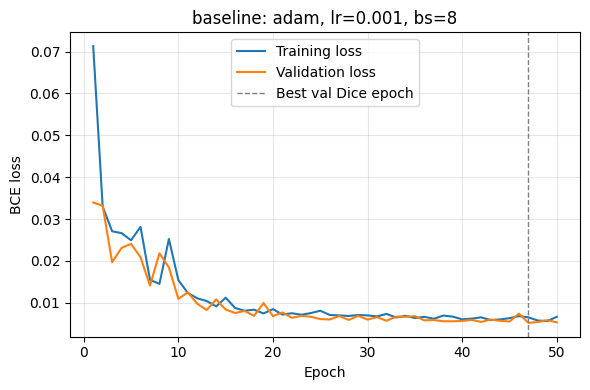

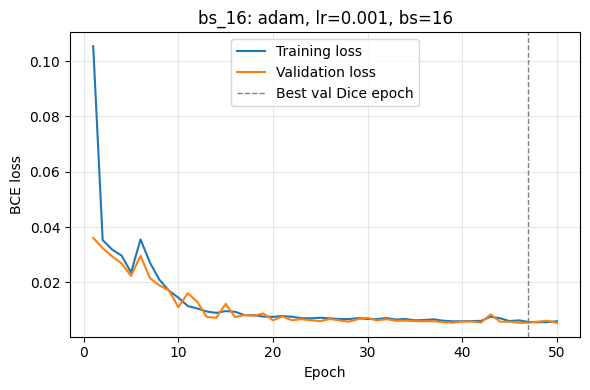

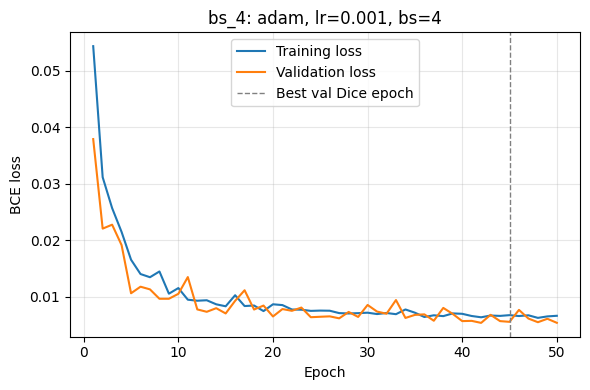

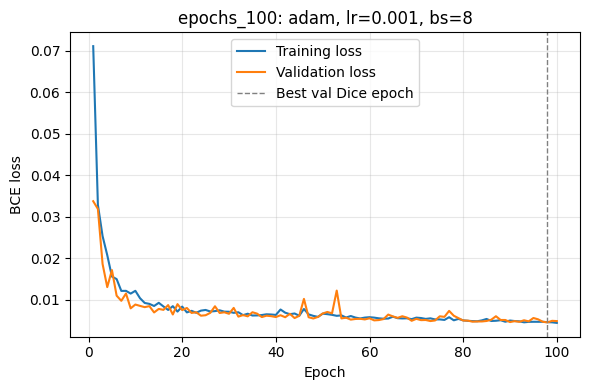

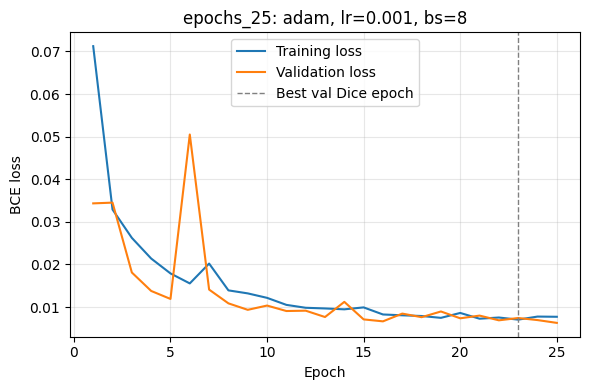

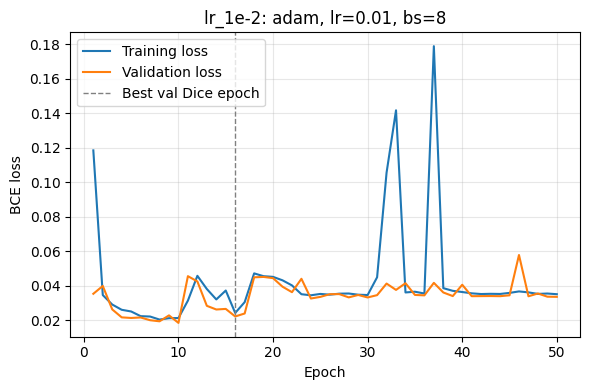

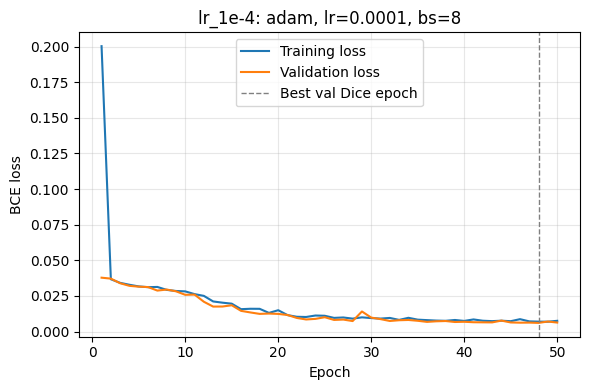

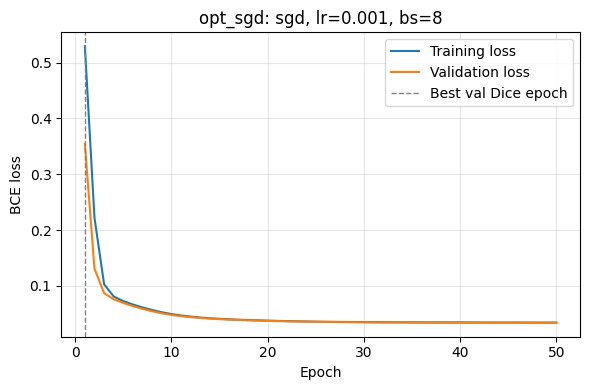

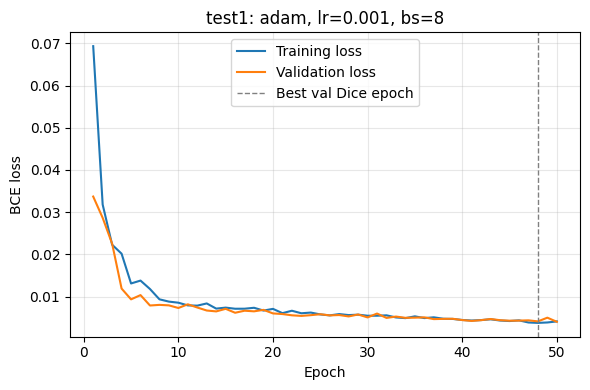

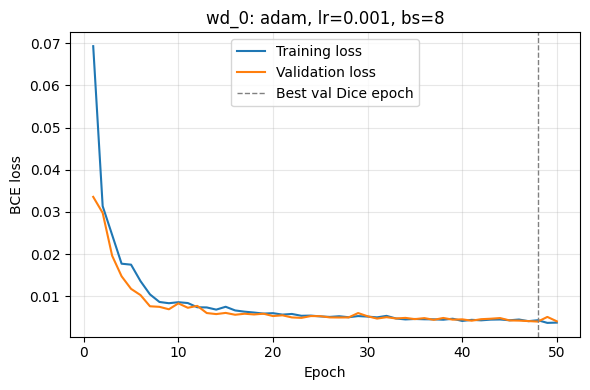

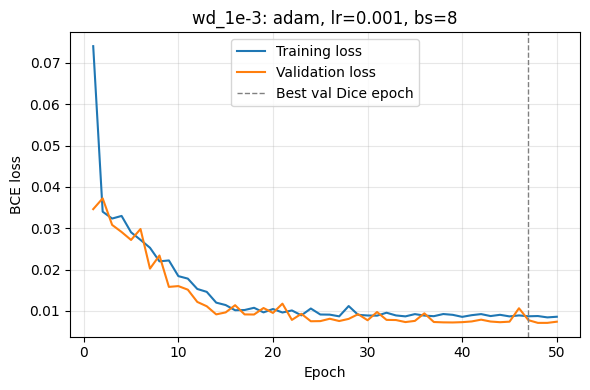

In [28]:
for name, r in runs.items():
    h = r['history']
    epochs = np.arange(1, len(h['train_loss']) + 1)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(epochs, h['train_loss'], label='Training loss')
    ax.plot(epochs, h['val_loss'], label='Validation loss')
    ax.axvline(r['best_epoch'] + 1, color='grey', ls='--', lw=1, label='Best val Dice epoch')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE loss')
    ax.set_title(f"{name}: {r['args']['optimizer']}, lr={r['args']['lr']}, bs={r['args']['batch_size']}")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f'loss_{name}.png'), dpi=200)
    plt.show()

## (3) Test Dice of the final model
The final model is the run with the highest validation Dice (chosen on validation, not test).

In [29]:
best_run = table.loc[0, 'run']
r = runs[best_run]
print(f'Final model: {best_run}')
print(f"Average test Dice (tau=0.5): {r['test_dice']:.4f} "
      f"+/- {np.std(r['test_dice_per_image']):.4f} over {len(r['test_dice_per_image'])} images")

Final model: wd_0
Average test Dice (tau=0.5): 0.8866 +/- 0.1569 over 180 images


## (4) Qualitative results
Shows the best and worst test images by Dice, with image, ground truth and prediction.

In [30]:
class MessidorSegDataset(Dataset):
    '''Preprocessed MESSIDOR split: <split_dir>/images/<name>.png, <split_dir>/masks/<name>_mask.png'''
    def __init__(self, split_dir):
        img_dir = os.path.join(split_dir, 'images')
        self.image_paths = [os.path.join(img_dir, f)
                            for f in sorted(os.listdir(img_dir)) if f.endswith('.png')]
        self.mask_paths = [os.path.join(split_dir, 'masks', f'{self.name(i)}_mask.png')
                           for i in range(len(self.image_paths))]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.asarray(Image.open(self.image_paths[idx]).convert('RGB'), dtype=np.float32) / 255.
        mask = (np.asarray(Image.open(self.mask_paths[idx]).convert('L')) > 127).astype(np.float32)
        return torch.from_numpy(image).permute(2, 0, 1), torch.from_numpy(mask).unsqueeze(0)

    def name(self, idx):
        return os.path.splitext(os.path.basename(self.image_paths[idx]))[0]

testset = MessidorSegDataset(os.path.join(DATA_ROOT, 'test'))

net = OpticDiscSegmenter().to(device)
net.load_state_dict(torch.load(os.path.join(RUNS_DIR, best_run, 'best.pth'), map_location=device)['net'])
net.eval()

def predict(idx):
    image, mask = testset[idx]
    with torch.no_grad():
        prob = torch.sigmoid(net(image.unsqueeze(0).to(device))).cpu()
    dice = dice_coefficient(prob, mask.unsqueeze(0)).item()
    return image, mask, prob[0], dice

def to_display(image):
    # undo arbitrary normalisation for display: per-channel min-max to [0, 1]
    img = image.permute(1, 2, 0).numpy()
    lo, hi = img.min(axis=(0, 1)), img.max(axis=(0, 1))
    return (img - lo) / (hi - lo + 1e-8)

dices = np.array(r['test_dice_per_image'])
order = np.argsort(dices)
selected = {'best': order[::-1][:2].tolist(), 'worst': order[:2].tolist()}
print(selected)

{'best': [133, 49], 'worst': [110, 116]}


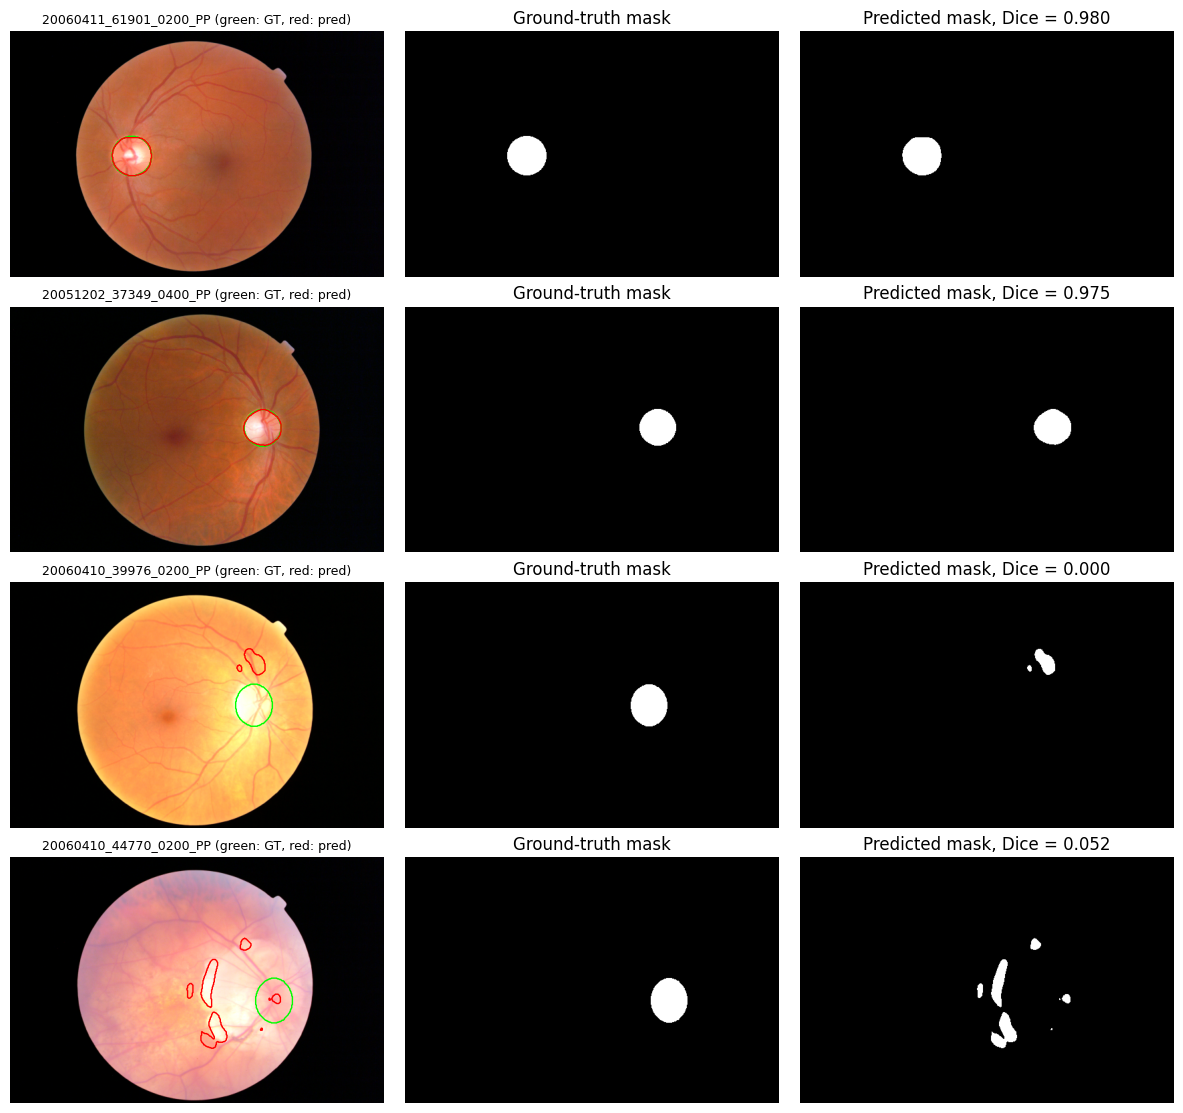

In [31]:
idxs = selected['best'] + selected['worst']
fig, axes = plt.subplots(len(idxs), 3, figsize=(12, 2.8 * len(idxs)))
for row, idx in enumerate(idxs):
    image, mask, prob, dice = predict(idx)
    img = to_display(image)
    pred = (prob[0] >= 0.5).numpy()
    axes[row, 0].imshow(img)
    axes[row, 0].contour(mask[0].numpy(), levels=[0.5], colors='lime', linewidths=1)
    axes[row, 0].contour(pred, levels=[0.5], colors='red', linewidths=1)
    axes[row, 0].set_title(f'{testset.name(idx)} (green: GT, red: pred)', fontsize=9)
    axes[row, 1].imshow(mask[0], cmap='gray')
    axes[row, 1].set_title('Ground-truth mask')
    axes[row, 2].imshow(pred, cmap='gray')
    axes[row, 2].set_title(f'Predicted mask, Dice = {dice:.3f}')
    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f'qualitative_{best_run}.png'), dpi=200)
plt.show()

## (5) Discussion
Notes on where the network does well or badly (e.g. low contrast, peripapillary atrophy, blood vessels crossing the disc boundary, the ellipse approximation of the ground truth, images with uneven illumination).

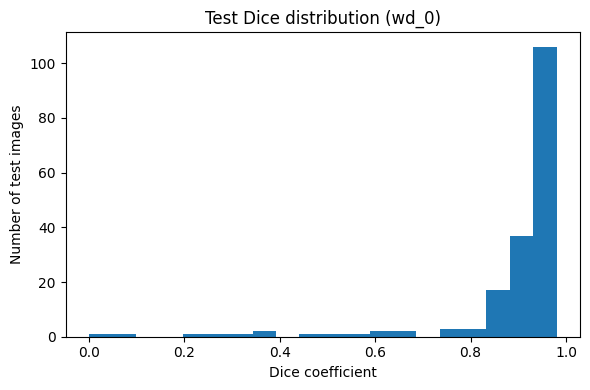

In [32]:
plt.figure(figsize=(6, 4))
plt.hist(dices, bins=20)
plt.xlabel('Dice coefficient')
plt.ylabel('Number of test images')
plt.title(f'Test Dice distribution ({best_run})')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'dice_hist_{best_run}.png'), dpi=200)
plt.show()